# Project 02

## Titanic Survival Prediction using Machine Learning

### AI & ML Internship Project

Name: Your Name

Organization: Pluto Academy

Dataset:
Titanic - Machine Learning from Disaster

Objective:
To build, train, evaluate, and compare multiple machine learning models for predicting passenger survival.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("/content/train.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.shape

(891, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [11]:
df.drop("Cabin", axis=1, inplace=True)

In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [13]:
le = LabelEncoder()

df["Sex"] = le.fit_transform(df["Sex"])

In [14]:
df["Embarked"] = le.fit_transform(df["Embarked"])

In [15]:
df.drop(["PassengerId","Name","Ticket"],axis=1,inplace=True)

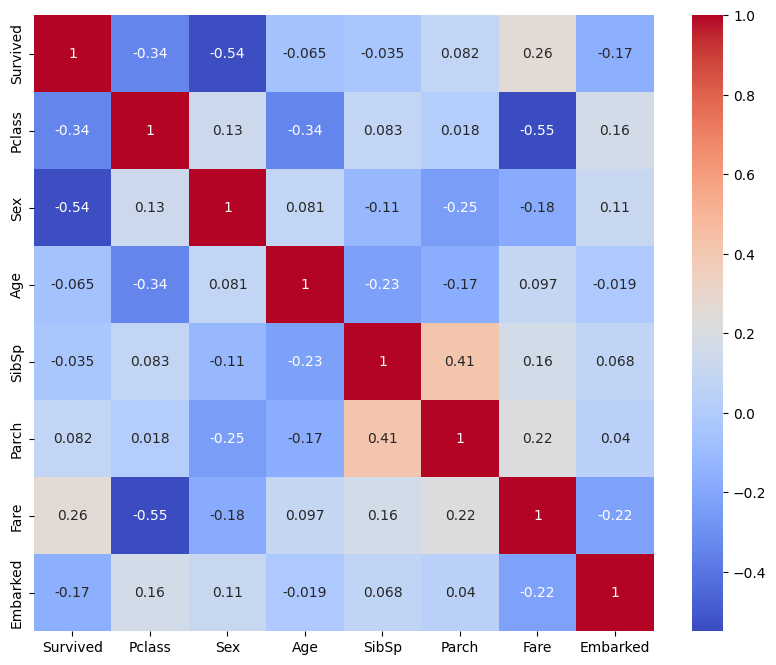

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

In [17]:
X = df.drop("Survived",axis=1)

y = df["Survived"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

In [19]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

In [20]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

LogisticRegression()

In [21]:
pred_lr=lr.predict(X_test)

In [22]:
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [23]:
knn=KNeighborsClassifier()

knn.fit(X_train,y_train)

pred_knn=knn.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import precision_score

from sklearn.metrics import recall_score

from sklearn.metrics import f1_score

In [25]:
accuracy_score(y_test,pred_lr)

0.8100558659217877

In [26]:
precision_score(y_test,pred_lr)

0.7857142857142857

In [27]:
recall_score(y_test,pred_lr)

0.7432432432432432

In [28]:
f1_score(y_test,pred_lr)

0.7638888888888888

In [29]:
comparison=pd.DataFrame({

'Model':['Logistic Regression','Random Forest','KNN'],

'Accuracy':[accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_knn)],

'Precision':[precision_score(y_test,pred_lr),
precision_score(y_test,pred_rf),
precision_score(y_test,pred_knn)],

'Recall':[recall_score(y_test,pred_lr),
recall_score(y_test,pred_rf),
recall_score(y_test,pred_knn)],

'F1 Score':[f1_score(y_test,pred_lr),
f1_score(y_test,pred_rf),
f1_score(y_test,pred_knn)]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Random Forest,0.821229,0.808824,0.743243,0.774648
2,KNN,0.703911,0.684211,0.527027,0.595420


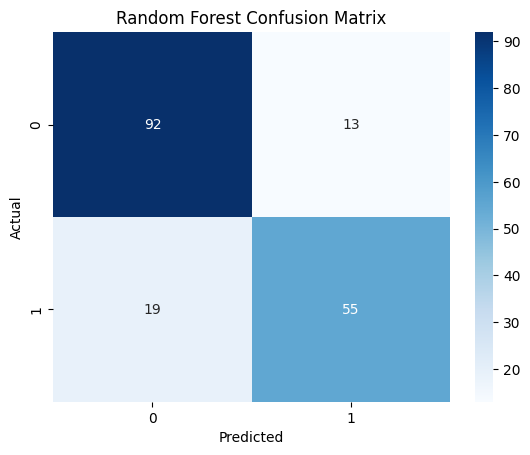

In [30]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [31]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance=importance.sort_values(by='Importance',ascending=False)

importance

,Feature,Importance
1,Sex,0.271410
5,Fare,0.265010
2,Age,0.249995
0,Pclass,0.086957
3,SibSp,0.053685
4,Parch,0.039897
6,Embarked,0.033044


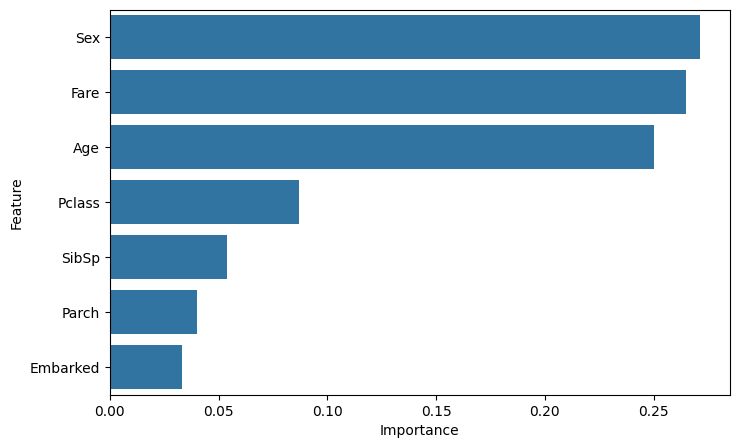

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(x='Importance',y='Feature',data=importance)

plt.show()

Random Forest achieved the highest accuracy and F1-score among all models. It effectively captured nonlinear relationships between passenger features and survival outcomes. The model handled feature interactions better than Logistic Regression and KNN, resulting in improved overall performance. Feature importance analysis showed that Sex, Fare, and Pclass were the most influential predictors. Therefore, Random Forest was selected as the best model.

Conclusion

The Titanic dataset was successfully cleaned and preprocessed.
Three machine learning models were trained and evaluated.
Random Forest produced the best overall performance.
Important features affecting survival were Sex, Pclass, Fare, and Age.
This project demonstrates the complete machine learning pipeline from preprocessing to model evaluation.